In [258]:
#import all the libraries
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [259]:
#define a scalar function
def f(x):
    return 3*x**2 - 4*x + 5 #parabola

In [260]:
f(3.0)

20.0

In [261]:
#create an array 
xs = np.arange(-5,5,0.25)

#call the function on this array
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

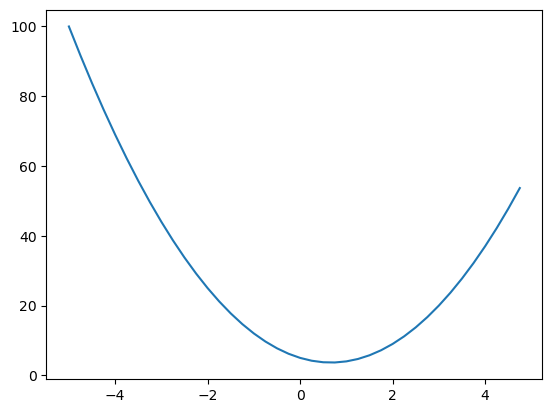

In [262]:
#plot this using matplotlib
plt.plot(xs,ys)

In [263]:
#take the derivative 
h = 0.00000001
x = 2/3
(f(x+h)-f(x))/h

0.0

In [264]:
#lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [265]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0
d1 = a*b+c
a+=h
d2 = a*b+c

#we check how much the change in inputs by h affect the slope
print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [266]:
#create the value object
class Value:
    def __init__(self,data,_children=(),_op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev =set(_children)
        self._op =_op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    #python does not know how to add two objects
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward
        
        return out
    
    def __rmul__(self, other): #other * self
        return self*other

    def __truediv__(self, other): #self / other
        return self*other**-1

    def __neg__(self): #-self
        return self * -1

    def __sub__(self, other): #self - other
        return self + (-other)
        
    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad = out.data * out.grad
            # equivalently:
            # self.grad += math.exp(x) * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def backward(self):
        
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

In [267]:
a = Value(2.0)
b = Value(4.0)
a-b

Value(data=-2.0)

In [268]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = Left to Right

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph create a rectangular{'record'} node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            #if the value is the result of some operation create a node for it
            dot.node(name =uid + n._op , label = n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        #connect n1 to the operation node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [269]:
# well we will see how c influences L
# we can use chain rule to to proves this if i want dl/dc i can simplhy do dl/df*df/dc. 
#so the gradient of c will be simply -2.0/1.0, same for e

In [270]:
# Build a simple neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh(); o.label ='o'
o.backward()

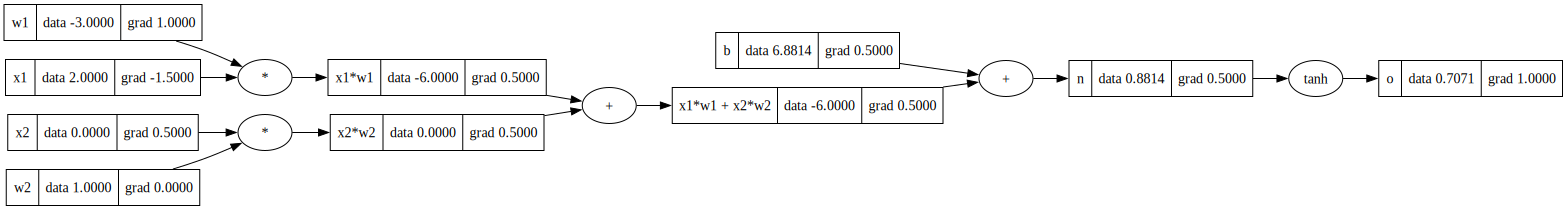

In [271]:
draw_dot(o)

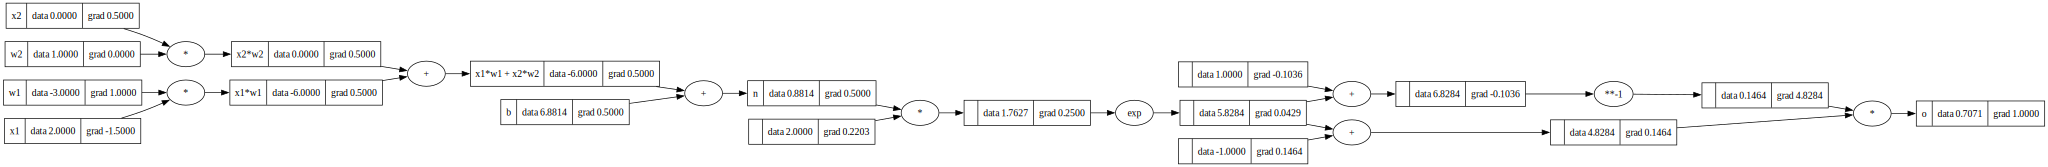

In [272]:
# Build a simple neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'
#------
e = (2*n).exp()
o = (e-1)/(e+1)
o.label ='o'
o.backward()
draw_dot(o)

In [273]:
#lets see the backpropagation
#o.grad  = 1.0
#n.grad = 0.5
#o = tanh
#do/dn = 1 - o**2
#x1w1x2w2.grad = 0.5
#b.grad = 0.5
#x1w1.grad = 0.5
#x2w2.grad = 0.5
#do/x1 = do/x1w1 * x1w1/x1
#x1.grad = 0.5*-3.0
#w1.grad = 0.5*2.0
#x2.grad = 0.5
#w2.grad = 0

In [274]:
import torch

In [275]:
x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b = torch.Tensor([6.8813735870195432]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [276]:
import random
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        #w*x+b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w  + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [435]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.1660316113882805)

In [436]:
len(n.parameters())

41

In [437]:
xs=[
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.1660316113882805),
 Value(data=-0.21293079483870644),
 Value(data=-0.04036665864027569),
 Value(data=-0.09680418171598122)]

In [438]:
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=0.695503273203628),
 Value(data=0.6194779337132303),
 Value(data=0.9208961498492292),
 Value(data=1.2029794130296632)]

In [468]:

for k in range(20): 
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    #reset the gradient each time to 0
    for p in n.parameters():
         p.grad = 0.0
        
    #backward pass
    loss.backward()

    #update(gradient descent)
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.001112577783603233
1 0.0011098612119771045
2 0.0011071575898633443
3 0.001104466825755187
4 0.0011017888290013307
5 0.001099123509795906
6 0.0010964707791687627
7 0.001093830548975704
8 0.00109120273188908
9 0.0010885872413883087
10 0.0010859839917506313
11 0.001083392898041949
12 0.0010808138761078554
13 0.0010782468425647074
14 0.0010756917147908478
15 0.0010731484109179797
16 0.0010706168498226271
17 0.0010680969511176785
18 0.0010655886351441162
19 0.0010630918229628226


In [469]:
ypred

[Value(data=0.9823283106918865),
 Value(data=-0.9893760038259849),
 Value(data=-0.9796529859502978),
 Value(data=0.9850356107870697)]